# 06 — Final walk-forward evaluation of the 2024/25 season

This notebook performs the only final out-of-time evaluation in the thesis project. The target season is 2024/25, predicted retrospectively in the order in which matches were played.

The feature lists, algorithms, hyperparameters, ensemble components, Poisson time-decay settings, and probability threshold were fixed using seasons 2021/22–2023/24. Nothing is selected or tuned from 2024/25 outcomes.

The evaluation answers four questions:

1. How accurate are the locked 1X2 and binary models on a genuinely later season?
2. Do structural and market branches differ when evaluated on the same matches?
3. Does one pooled five-league model outperform five league-specific models?
4. How does predictive performance evolve as the models learn from completed 2024/25 rounds?

## 1. Information sources and sealed-test rule

The analytical rows were prepared from [Understat](https://understat.com/), [ClubElo](http://clubelo.com/), [SoFIFA](https://sofifa.com/), and [Football-Data](https://www.football-data.co.uk/). Their variables, timestamps, joins, and limitations are documented in Notebooks 01 and 02.

The final-test rule is:

$$
\text{model choice information}\subseteq\{\text{matches completed by 26 May 2024}\}.
$$

During 2024/25, a result may enter the training sample only after it has been completed. Its pre-match features may then update the state used for later fixtures. The current fixture's result, goals, xG, and post-match statistics never enter its own predictors.

Reading the locked registries printed by Notebooks 03 and 05 prevents this notebook from silently rerunning feature selection after the final season is visible.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import time
import warnings

logical_cores = max(1, os.cpu_count() or 1)
os.environ["LOKY_MAX_CPU_COUNT"] = str(max(1, min(8, logical_cores - 1)))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "match_prediction_matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification import make_classifier, make_preprocessor, ordered_probabilities
from src.config import DEVELOPMENT_SEASONS, FINAL_TEST_SEASON, PROCESSED_DATA_DIR
from src.evaluation import evaluate_binary, evaluate_multiclass, wilson_accuracy_interval
from src.final_model_registry import load_locked_model_registries, registry_frame
from src.poisson_models import fit_poisson_model, poisson_probabilities
from src.validation import assign_walk_forward_blocks

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 45)
pd.set_option("display.max_rows", 5000)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)

LEAGUES = {
    "BUNDESLIGA": "Bundesliga",
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "LIGUE_1": "Ligue 1",
    "SERIE_A": "Serie A",
}
SCOPE_NAMES = {**LEAGUES, "POOLED": "Pooled five-league model"}
RESULT_LABELS = np.array(["H", "D", "A"])
COLOURS = {
    "structural": "#1F4E79",
    "market": "#D9A62E",
    "poisson": "#4E9F6D",
    "aggregate": "#7A5195",
    "baseline": "#9AA6B2",
    "target": "#C44E52",
}
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 10,
    "grid.alpha": 0.22,
})

## 2. Exact prediction horizon

Each of the five competitions is a complete double round-robin season in the source table:

- 18-team Bundesliga and Ligue 1: $18\times17=306$ matches;
- 20-team Premier League, La Liga, and Serie A: $20\times19=380$ matches.

The expected total is therefore

$$
306+380+380+306+380=1{,}752.
$$

The next cells reconcile these counts with the processed data before any model is fitted.

In [2]:
features = pd.read_csv(PROCESSED_DATA_DIR / "match_features.csv", parse_dates=["date"])
features = features.sort_values(["date", "league_id", "game_id"]).reset_index(drop=True)

development = features.loc[
    features["season_id"].isin(DEVELOPMENT_SEASONS)
    & features["sample_role"].eq("development")
].copy()
final_test = features.loc[
    features["season_id"].eq(FINAL_TEST_SEASON)
    & features["sample_role"].eq("walk_forward_test")
].copy()

assert len(final_test) == 1752
assert final_test[["home_goals", "away_goals", "target_1x2", "home_win"]].notna().all().all()
assert development["date"].max() < final_test["date"].min()

final_test_blocked, league_block_summary = assign_walk_forward_blocks(final_test)

# Pooled models are refitted once per common Friday--Thursday football week.
pooled_offset = (final_test_blocked["date"].dt.dayofweek - 4) % 7
final_test_blocked["pooled_week_start"] = (
    final_test_blocked["date"] - pd.to_timedelta(pooled_offset, unit="D")
)
pooled_weeks = sorted(final_test_blocked["pooled_week_start"].unique())
pooled_block_map = {week: number for number, week in enumerate(pooled_weeks, start=1)}
final_test_blocked["pooled_walk_block"] = final_test_blocked["pooled_week_start"].map(pooled_block_map)

display(final_test_blocked[[
    "date", "league_id", "home_team", "away_team", "target_1x2", "home_win",
    "walk_block", "walk_block_type", "pooled_walk_block", "sample_role",
]].sample(10, random_state=42))

,date,league_id,home_team,away_team,target_1x2,home_win,walk_block,walk_block_type,pooled_walk_block,sample_role
5726,2024-10-05,LIGUE_1,Lille,Toulouse,H,1,7,complete_round,8,walk_forward_test
5812,2024-10-26,EPL,Brentford,Ipswich,H,1,9,complete_round,10,walk_forward_test
5809,2024-10-26,BUNDESLIGA,St. Pauli,Wolfsburg,D,0,8,complete_round,10,walk_forward_test
5866,2024-11-02,EPL,Bournemouth,Manchester City,H,1,10,complete_round,11,walk_forward_test
6913,2025-04-20,SERIE_A,Bologna,Inter,H,1,36,complete_round,34,walk_forward_test
6646,2025-03-08,EPL,Brighton,Fulham,H,1,30,complete_round,28,walk_forward_test
6938,2025-04-26,BUNDESLIGA,Bayern Munich,Mainz 05,H,1,31,complete_round,35,walk_forward_test
6203,2024-12-28,SERIE_A,Cagliari,Inter,A,0,18,complete_round,18,walk_forward_test
6697,2025-03-15,LALIGA,Girona,Valencia,D,0,33,complete_round,29,walk_forward_test
7150,2025-05-25,SERIE_A,Venezia,Juventus,A,0,41,complete_round,39,walk_forward_test


The representative rows show the two block identifiers. `walk_block` belongs to the league-specific schedule. `pooled_walk_block` is a common week across all leagues. Targets are visible only because this is the final evaluation; they are never passed to a model before its probability is produced.

In [3]:
horizon_rows = []
for league_id, league_name in LEAGUES.items():
    league = final_test_blocked.loc[final_test_blocked["league_id"].eq(league_id)]
    blocks = league_block_summary.loc[league_block_summary["league_id"].eq(league_id)]
    expected = 306 if league_id in {"BUNDESLIGA", "LIGUE_1"} else 380
    horizon_rows.append({
        "league": league_name,
        "fixtures_in_source": len(league),
        "expected_double_round_robin": expected,
        "difference": len(league) - expected,
        "first_prediction_date": league["date"].min(),
        "last_prediction_date": league["date"].max(),
        "league_refit_blocks": blocks["walk_block"].nunique(),
        "complete_round_blocks": blocks["walk_block_type"].eq("complete_round").sum(),
        "weekly_exception_blocks": blocks["walk_block_type"].eq("weekly_exception").sum(),
    })

prediction_horizon = pd.DataFrame(horizon_rows)
prediction_horizon.loc[len(prediction_horizon)] = {
    "league": "All five leagues",
    "fixtures_in_source": len(final_test_blocked),
    "expected_double_round_robin": 1752,
    "difference": len(final_test_blocked) - 1752,
    "first_prediction_date": final_test_blocked["date"].min(),
    "last_prediction_date": final_test_blocked["date"].max(),
    "league_refit_blocks": league_block_summary.shape[0],
    "complete_round_blocks": league_block_summary["walk_block_type"].eq("complete_round").sum(),
    "weekly_exception_blocks": league_block_summary["walk_block_type"].eq("weekly_exception").sum(),
}

display(
    prediction_horizon.style
    .format({"first_prediction_date": "{:%d %b %Y}", "last_prediction_date": "{:%d %b %Y}"})
    .hide(axis="index")
)
print(f"Common pooled refit weeks: {len(pooled_weeks)}")

league,fixtures_in_source,expected_double_round_robin,difference,first_prediction_date,last_prediction_date,league_refit_blocks,complete_round_blocks,weekly_exception_blocks
Bundesliga,306,306,0,23 Aug 2024,17 May 2025,34,34,0
Premier League,380,380,0,16 Aug 2024,25 May 2025,42,33,9
La Liga,380,380,0,15 Aug 2024,25 May 2025,45,30,15
Ligue 1,306,306,0,16 Aug 2024,17 May 2025,36,32,4
Serie A,380,380,0,17 Aug 2024,25 May 2025,41,33,8
All five leagues,1752,1752,0,15 Aug 2024,25 May 2025,198,162,36


Common pooled refit weeks: 39


All 1,752 expected fixtures are present. Predictions cover **15 August 2024 through 25 May 2025**. A weekly exception does not mean that a row is missing from the dataset. It means that the Friday–Thursday source schedule does not contain exactly one full set of teams, usually because a match was postponed, brought forward, or played as a midweek remainder.

### 2.1 Definition of a refit block

The source does not provide an official matchday number. A reproducible schedule-based rule is therefore used:

1. a football week runs from Friday through Thursday, keeping weekend fixtures and Monday matches together;
2. the earliest 9 or 10 fixtures form a `complete_round` only when every league team appears exactly once;
3. two consecutive complete rounds in one week are separated, allowing a refit before the midweek round;
4. every remaining partial or irregular set is one `weekly_exception` block.

For block $b$ with first date $s_b$, the training sample is

$$
\mathcal D_b=\mathcal D_{2021/22:2023/24}
\cup\{i\in2024/25:d_i<s_b\}.
$$

The locked model is fitted once to $\mathcal D_b$ and predicts every fixture assigned to block $b$. If a pre-match feature changes after an earlier match in the same block, its row may reflect that already completed match, but the fitted model coefficients remain fixed until the next refit.

In [4]:
block_audit = league_block_summary.copy()
block_audit["league"] = block_audit["league_id"].map(LEAGUES)
display(
    block_audit[[
        "league", "walk_block", "walk_block_type", "block_start", "block_end",
        "matches", "expected_round_matches", "unique_teams",
    ]]
    .style
    .format({"block_start": "{:%d %b %Y}", "block_end": "{:%d %b %Y}"})
    .hide(axis="index")
)

league,walk_block,walk_block_type,block_start,block_end,matches,expected_round_matches,unique_teams
Bundesliga,1,complete_round,23 Aug 2024,25 Aug 2024,9,9,18
Bundesliga,2,complete_round,30 Aug 2024,01 Sep 2024,9,9,18
Bundesliga,3,complete_round,13 Sep 2024,15 Sep 2024,9,9,18
Bundesliga,4,complete_round,20 Sep 2024,22 Sep 2024,9,9,18
Bundesliga,5,complete_round,27 Sep 2024,29 Sep 2024,9,9,18
Bundesliga,6,complete_round,04 Oct 2024,06 Oct 2024,9,9,18
Bundesliga,7,complete_round,18 Oct 2024,20 Oct 2024,9,9,18
Bundesliga,8,complete_round,25 Oct 2024,27 Oct 2024,9,9,18
Bundesliga,9,complete_round,01 Nov 2024,03 Nov 2024,9,9,18
Bundesliga,10,complete_round,08 Nov 2024,10 Nov 2024,9,9,18


The block table is the timing contract for the final evaluation. It shows exactly when each prediction set begins and ends, how many fixtures it contains, and whether it represents a complete round or a weekly exception.

## 3. Locked model registries

The development notebooks printed one final row for every scope and branch. These rows are loaded without executing their selection code. The loader validates that:

- 12 entries exist for each target: five leagues plus pooled, each structural and market;
- structural branches contain no market variables;
- `league_id` is used only by pooled classifiers;
- every entry has a non-empty fixed feature list.

In [5]:
multiclass_registry, binary_registry = load_locked_model_registries(PROJECT_ROOT / "notebooks")
locked_registry_summary = pd.concat([
    registry_frame(multiclass_registry, "1X2"),
    registry_frame(binary_registry, "binary home win"),
], ignore_index=True)

display(
    locked_registry_summary[[
        "target", "scope", "branch", "algorithm", "hyperparameters", "features", "feature_names",
    ]]
    .style
    .hide(axis="index")
)

target,scope,branch,algorithm,hyperparameters,features,feature_names
1X2,Bundesliga,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameters': {'n_neighbors': 100, 'weights': 'distance'}}, {'model': 'logistic', 'model_label': 'Multinomial logistic regression', 'parameters': {'C': 0.01}}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameters': {'C': 0.01}}]",18,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_span_5, diff_points_mean_last_5, diff_rest_days, home_promoted_or_returning, away_promoted_or_returning, market_prob_home, market_prob_draw, market_overround, market_available, away_clubelo_rating, diff_deep_completions_season_mean_pre, home_clubelo_rating, away_points_season_mean_pre"
1X2,Bundesliga,structural,Multinomial logistic regression,{'C': 0.01},14,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_span_5, diff_points_mean_last_5, diff_rest_days, home_promoted_or_returning, away_promoted_or_returning, away_clubelo_rating, diff_deep_completions_season_mean_pre, home_clubelo_rating, away_points_season_mean_pre"
1X2,Premier League,market,CatBoost,"{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}",18,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_span_5, diff_points_mean_last_5, diff_rest_days, home_promoted_or_returning, away_promoted_or_returning, market_prob_home, market_prob_draw, market_overround, market_available, home_clubelo_rating, diff_xg_for_season_mean_pre, away_deep_completions_mean_last_5, diff_xg_diff_mean_last_10"
1X2,Premier League,structural,Equal-weight top-three ensemble,"[{'model': 'catboost', 'model_label': 'CatBoost', 'parameters': {'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameters': {'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}}, {'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameters': {'n_neighbors': 100, 'weights': 'distance'}}]",14,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_span_5, diff_points_mean_last_5, diff_rest_days, home_promoted_or_returning, away_promoted_or_returning, home_clubelo_rating, diff_xg_for_season_mean_pre, away_deep_completions_mean_last_5, diff_xg_diff_mean_last_10"
1X2,La Liga,market,k-nearest neighbours,"{'n_neighbors': 100, 'weights': 'distance'}",18,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_span_5, diff_points_mean_last_5, diff_rest_days, home_promoted_or_returning, away_promoted_or_returning, market_prob_home, market_prob_draw, market_overround, market_available, home_clubelo_rating, away_deep_completions_season_mean_pre, away_sofifa_top11_overall, diff_deep_completions_mean_last_10"
1X2,La Liga,structural,k-nearest neighbours,"{'n_neighbors': 100, 'weights': 'distance'}",14,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_span_5, diff_points_mean_last_5, diff_rest_days, home_promoted_or_returning, away_promoted_or_returning, home_clubelo_rating, away_deep_completions_season_mean_pre, away_sofifa_top11_overall, diff_deep_completions_mean_last_10"
1X2,Ligue 1,market,Equal-weight top-three ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameters': {'n_neighbors': 100, 'weights': 'distance'}}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameters': {'C': 0.01}}, {'model': 'catboost', 'model_label': 'CatBoost', 'parameters': {'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}}]",22,"elo_diff_pre, clubelo_diff, clubelo_available, diff_sofifa_top11_overall, sofifa_available, diff_xg_diff_ewm_

The wide table states the exact algorithm, hyperparameters, and feature names for all 24 locked branches. The information cutoff is **day-before/pre-match** for structural variables and **archived closing-market** for market variables. The training period begins in 2021/22 and expands only with completed 2024/25 blocks.

In [6]:
registry_input_rows = []
for target, registry in [("1X2", multiclass_registry), ("binary home win", binary_registry)]:
    for (scope_code, branch), entry in sorted(registry.items()):
        for position, feature in enumerate(entry["features"], start=1):
            registry_input_rows.append({
                "target": target,
                "scope": SCOPE_NAMES[scope_code],
                "scope_code": scope_code,
                "branch": branch,
                "algorithm": entry["model_label"],
                "position": position,
                "feature": feature,
                "information_cutoff": "archived closing-market / pre-match" if feature.startswith("market_") else "known before the fixture",
            })

locked_input_registry = pd.DataFrame(registry_input_rows)
display(locked_input_registry.style.hide(axis="index"))

target,scope,scope_code,branch,algorithm,position,feature,information_cutoff
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,1,elo_diff_pre,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,2,clubelo_diff,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,3,clubelo_available,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,4,diff_sofifa_top11_overall,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,5,sofifa_available,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,6,diff_xg_diff_ewm_span_5,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,7,diff_points_mean_last_5,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,8,diff_rest_days,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,9,home_promoted_or_returning,known before the fixture
1X2,Bundesliga,BUNDESLIGA,market,Equal-weight top-three ensemble,10,away_promoted_or_returning,known before the fixture


This long input table is intentionally explicit. It is the final-test counterpart of the feature registries in Notebooks 03 and 05 and makes accidental feature drift visible.

## 4. Walk-forward fitting functions

At block $b$, the preprocessing transformation and model parameters are re-estimated from $\mathcal D_b$:

$$
\widehat f_b=\operatorname{Fit}(\mathcal D_b;\mathcal F,\mathcal A,\eta),
$$

where $\mathcal F$ is the locked feature list, $\mathcal A$ the locked algorithm, and $\eta$ the locked hyperparameters. Only fitted numerical values change; the modelling decisions do not.

For an ensemble with $M$ locked components,

$$
\widehat{\boldsymbol p}_{i,b}=\frac{1}{M}\sum_{m=1}^{M}
\widehat{\boldsymbol p}^{(m)}_{i,b}.
$$

In [7]:
def fit_locked_probabilities(entry, train, validation, target):
    # Fit one locked registry entry and return ordered probabilities.
    preprocessor = make_preprocessor(entry["features"])
    x_train = preprocessor.fit_transform(train[entry["features"]])
    x_validation = preprocessor.transform(validation[entry["features"]])
    specifications = (
        entry["components"]
        if entry["model"] == "ensemble"
        else [{"model": entry["model"], "parameters": entry["parameters"]}]
    )
    component_probabilities = []
    for specification in specifications:
        model_name = specification["model"]
        model = make_classifier(
            model_name,
            specification["parameters"],
            task="multiclass" if target == "1X2" else "binary",
        )
        if target == "1X2" and model_name == "xgboost":
            y_train = pd.Categorical(train["target_1x2"], categories=RESULT_LABELS).codes
            model.fit(x_train, y_train)
            probability = model.predict_proba(x_validation)
        else:
            y_train = train["target_1x2"] if target == "1X2" else train["home_win"]
            model.fit(x_train, y_train)
            order = RESULT_LABELS if target == "1X2" else np.array([0, 1])
            probability = ordered_probabilities(model, x_validation, order)
            if target == "binary":
                probability = probability[:, 1]
        component_probabilities.append(probability)
    return np.mean(component_probabilities, axis=0)


def training_sample(scope_code, block_start):
    # Return development history plus completed final-season matches.
    scope_mask = pd.Series(True, index=features.index) if scope_code == "POOLED" else features["league_id"].eq(scope_code)
    eligible_role = features["sample_role"].eq("development") | (
        features["sample_role"].eq("walk_forward_test") & features["date"].lt(block_start)
    )
    return features.loc[scope_mask & eligible_role].copy()

## 5. Produce the locked ML predictions

League-specific models follow the league block table. Pooled models are refitted at the beginning of every common Friday–Thursday week because five competitions do not complete their rounds on the same dates.

Each output row stores the model-training boundary, training sample size, predicted probabilities, observed result, and the block that authorised the refit. These fields make the chronology auditable.

In [8]:
walk_rows = []
refit_rows = []
run_start = time.perf_counter()

for scope_code in [*LEAGUES, "POOLED"]:
    if scope_code == "POOLED":
        scope_test = final_test_blocked.copy()
        block_column = "pooled_walk_block"
        scope_type = "pooled"
    else:
        scope_test = final_test_blocked.loc[final_test_blocked["league_id"].eq(scope_code)].copy()
        block_column = "walk_block"
        scope_type = "league-specific"

    for block_number, validation in scope_test.groupby(block_column, sort=True):
        validation = validation.sort_values(["date", "game_id"])
        block_start = validation["date"].min()
        train = training_sample(scope_code, block_start)
        train_frequency = train["target_1x2"].value_counts(normalize=True).reindex(RESULT_LABELS).fillna(0)
        train_home_rate = train["home_win"].mean()
        block_type = (
            "weekly_pooled_refit"
            if scope_code == "POOLED"
            else validation["walk_block_type"].iloc[0]
        )
        refit_rows.append({
            "scope_code": scope_code,
            "scope": SCOPE_NAMES[scope_code],
            "scope_type": scope_type,
            "walk_block": int(block_number),
            "walk_block_type": block_type,
            "prediction_start": validation["date"].min(),
            "prediction_end": validation["date"].max(),
            "training_end": train["date"].max(),
            "training_matches": len(train),
            "predicted_matches": len(validation),
        })

        for branch in ["structural", "market"]:
            p_1x2 = fit_locked_probabilities(
                multiclass_registry[(scope_code, branch)], train, validation, "1X2"
            )
            p_binary = fit_locked_probabilities(
                binary_registry[(scope_code, branch)], train, validation, "binary"
            )
            part = pd.DataFrame({
                "scope_code": scope_code,
                "scope": SCOPE_NAMES[scope_code],
                "scope_type": scope_type,
                "branch": branch,
                "walk_block": int(block_number),
                "walk_block_type": block_type,
                "block_start": block_start,
                "training_end": train["date"].max(),
                "training_matches": len(train),
                "league_id": validation["league_id"].to_numpy(),
                "game_id": validation["game_id"].to_numpy(),
                "date": validation["date"].to_numpy(),
                "home_team": validation["home_team"].to_numpy(),
                "away_team": validation["away_team"].to_numpy(),
                "observed_1x2": validation["target_1x2"].to_numpy(),
                "observed_home_win": validation["home_win"].to_numpy(dtype=int),
                "p_1x2_home": p_1x2[:, 0],
                "p_1x2_draw": p_1x2[:, 1],
                "p_1x2_away": p_1x2[:, 2],
                "p_binary_home": p_binary,
                "train_frequency_home": train_frequency["H"],
                "train_frequency_draw": train_frequency["D"],
                "train_frequency_away": train_frequency["A"],
                "train_home_win_rate": train_home_rate,
                "market_prob_home": validation["market_prob_home"].to_numpy(),
                "market_prob_draw": validation["market_prob_draw"].to_numpy(),
                "market_prob_away": validation["market_prob_away"].to_numpy(),
                "market_available": validation["market_available"].to_numpy(),
            })
            walk_rows.append(part)

    print(f"Completed locked walk-forward fits for {SCOPE_NAMES[scope_code]}.")

locked_predictions = pd.concat(walk_rows, ignore_index=True)
refit_log = pd.DataFrame(refit_rows)
print(f"ML prediction rows: {len(locked_predictions):,}")
print(f"Elapsed minutes: {(time.perf_counter() - run_start) / 60:.1f}")

Completed locked walk-forward fits for Bundesliga.


Completed locked walk-forward fits for Premier League.


Completed locked walk-forward fits for La Liga.


Completed locked walk-forward fits for Ligue 1.


Completed locked walk-forward fits for Serie A.


Completed locked walk-forward fits for Pooled five-league model.
ML prediction rows: 7,008
Elapsed minutes: 5.6


The progress messages confirm that every scope finished. The number of prediction rows is larger than 1,752 because every fixture receives structural and market probabilities from both its league-specific model and the pooled model.

In [9]:
assert len(locked_predictions) == 1752 * 2 * 2
assert locked_predictions[[
    "p_1x2_home", "p_1x2_draw", "p_1x2_away", "p_binary_home"
]].notna().all().all()
assert np.allclose(
    locked_predictions[["p_1x2_home", "p_1x2_draw", "p_1x2_away"]].sum(axis=1),
    1.0,
)
assert locked_predictions["p_binary_home"].between(0, 1).all()
assert (locked_predictions["training_end"] < locked_predictions["block_start"]).all()

display(Markdown("### Complete refit log"))
display(
    refit_log.style
    .format({
        "prediction_start": "{:%d %b %Y}", "prediction_end": "{:%d %b %Y}",
        "training_end": "{:%d %b %Y}",
    })
    .hide(axis="index")
)

### Complete refit log

scope_code,scope,scope_type,walk_block,walk_block_type,prediction_start,prediction_end,training_end,training_matches,predicted_matches
BUNDESLIGA,Bundesliga,league-specific,1,complete_round,23 Aug 2024,25 Aug 2024,18 May 2024,918,9
BUNDESLIGA,Bundesliga,league-specific,2,complete_round,30 Aug 2024,01 Sep 2024,25 Aug 2024,927,9
BUNDESLIGA,Bundesliga,league-specific,3,complete_round,13 Sep 2024,15 Sep 2024,01 Sep 2024,936,9
BUNDESLIGA,Bundesliga,league-specific,4,complete_round,20 Sep 2024,22 Sep 2024,15 Sep 2024,945,9
BUNDESLIGA,Bundesliga,league-specific,5,complete_round,27 Sep 2024,29 Sep 2024,22 Sep 2024,954,9
BUNDESLIGA,Bundesliga,league-specific,6,complete_round,04 Oct 2024,06 Oct 2024,29 Sep 2024,963,9
BUNDESLIGA,Bundesliga,league-specific,7,complete_round,18 Oct 2024,20 Oct 2024,06 Oct 2024,972,9
BUNDESLIGA,Bundesliga,league-specific,8,complete_round,25 Oct 2024,27 Oct 2024,20 Oct 2024,981,9
BUNDESLIGA,Bundesliga,league-specific,9,complete_round,01 Nov 2024,03 Nov 2024,27 Oct 2024,990,9
BUNDESLIGA,Bundesliga,league-specific,10,complete_round,08 Nov 2024,10 Nov 2024,03 Nov 2024,999,9


The assertions enforce the four most important mechanical conditions: every required probability exists, 1X2 rows sum to one, binary probabilities lie in $[0,1]$, and every training boundary is earlier than its prediction block.

## 6. Walk-forward Poisson reference

The Poisson time-decay settings were locked in Notebook 04:

- Bundesliga: no time decay;
- Premier League: 365-day half-life;
- La Liga, Ligue 1, and Serie A: 730-day half-life.

The score model is refitted on the same league blocks as the league-specific classifiers. Its score matrix produces both 1X2 probabilities and $P(X>Y)$, so no additional binary Poisson model is fitted.

In [10]:
POISSON_DECAY = {
    "BUNDESLIGA": 0.0,
    "EPL": np.log(2) / 365.0,
    "LALIGA": np.log(2) / 730.0,
    "LIGUE_1": np.log(2) / 730.0,
    "SERIE_A": np.log(2) / 730.0,
}

poisson_parts = []
for league_id, league_name in LEAGUES.items():
    league_test = final_test_blocked.loc[final_test_blocked["league_id"].eq(league_id)]
    for block_number, validation in league_test.groupby("walk_block", sort=True):
        validation = validation.sort_values(["date", "game_id"])
        block_start = validation["date"].min()
        train = training_sample(league_id, block_start)
        fit = fit_poisson_model(train, decay_rate=POISSON_DECAY[league_id])
        probability, lambda_home, lambda_away = poisson_probabilities(fit, validation)
        poisson_parts.append(pd.DataFrame({
            "league_id": league_id,
            "league": league_name,
            "walk_block": int(block_number),
            "game_id": validation["game_id"].to_numpy(),
            "date": validation["date"].to_numpy(),
            "observed_1x2": validation["target_1x2"].to_numpy(),
            "observed_home_win": validation["home_win"].to_numpy(dtype=int),
            "p_poisson_home": probability[:, 0],
            "p_poisson_draw": probability[:, 1],
            "p_poisson_away": probability[:, 2],
            "lambda_home": lambda_home,
            "lambda_away": lambda_away,
            "optimizer_success": fit.success,
        }))

poisson_walk_predictions = pd.concat(poisson_parts, ignore_index=True)
assert len(poisson_walk_predictions) == 1752
assert poisson_walk_predictions["optimizer_success"].all()
print(f"Successful Poisson block fits: {league_block_summary.shape[0]} / {league_block_summary.shape[0]}")

Successful Poisson block fits: 198 / 198


All Poisson refits converged. The Poisson probabilities are now joined to the locked ML rows by league and match identifier for fair same-match comparisons.

In [11]:
poisson_columns = [
    "league_id", "game_id", "p_poisson_home", "p_poisson_draw", "p_poisson_away",
    "lambda_home", "lambda_away",
]
locked_predictions = locked_predictions.merge(
    poisson_walk_predictions[poisson_columns],
    on=["league_id", "game_id"],
    how="left",
    validate="many_to_one",
)
assert locked_predictions[["p_poisson_home", "p_poisson_draw", "p_poisson_away"]].notna().all().all()

## 7. Final evaluation measures and uncertainty

The metric definitions are given in Notebooks 03 and 05. This notebook additionally reports a 95% Wilson interval for accuracy. For $c$ correct predictions among $n$ matches and $z=1.96$,

$$
\widetilde p=\frac{c+z^2/2}{n+z^2},
$$

$$
\operatorname{halfwidth}=\frac{z}{1+z^2/n}
\sqrt{\frac{\widehat p(1-\widehat p)}{n}+\frac{z^2}{4n^2}}.
$$

The interval describes binomial sampling uncertainty. Football matches are not perfectly independent, so it should be read as an approximate uncertainty summary rather than a complete time-series model.

In [12]:
def multiclass_result_row(group, extra=None):
    probability = group[["p_1x2_home", "p_1x2_draw", "p_1x2_away"]].to_numpy()
    metrics = evaluate_multiclass(group["observed_1x2"], probability)
    predicted = RESULT_LABELS[np.argmax(probability, axis=1)]
    correct = int((predicted == group["observed_1x2"].to_numpy()).sum())
    lower, upper = wilson_accuracy_interval(correct, len(group))
    return {**(extra or {}), **metrics, "accuracy_ci_low": lower, "accuracy_ci_high": upper}


def binary_result_row(group, probability_column="p_binary_home", extra=None):
    metrics = evaluate_binary(group["observed_home_win"], group[probability_column])
    correct = int(
        ((group[probability_column].to_numpy() >= 0.5).astype(int) == group["observed_home_win"].to_numpy()).sum()
    )
    lower, upper = wilson_accuracy_interval(correct, len(group))
    return {**(extra or {}), **metrics, "accuracy_ci_low": lower, "accuracy_ci_high": upper}

## 8. Locked ML performance by scope and branch

The first result tables contain only the locked direct ML branches. League-specific rows cover one competition; pooled rows cover all five competitions together.

In [13]:
multiclass_rows = []
binary_rows = []
for keys, group in locked_predictions.groupby(["scope_code", "scope", "scope_type", "branch"], sort=True):
    scope_code, scope, scope_type, branch = keys
    common = {"scope_code": scope_code, "scope": scope, "scope_type": scope_type, "branch": branch}
    multiclass_rows.append(multiclass_result_row(group, common))
    binary_rows.append(binary_result_row(group, extra=common))

final_multiclass_summary = pd.DataFrame(multiclass_rows).sort_values(["scope", "branch"])
final_binary_summary = pd.DataFrame(binary_rows).sort_values(["scope", "branch"])

display(Markdown("### Final 1X2 performance"))
display(
    final_multiclass_summary[[
        "scope", "scope_type", "branch", "n_matches", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
        "macro_f1", "home_win_recall", "draw_recall", "away_win_recall", "log_loss", "brier_score",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "accuracy_ci_low": "{:.2%}", "accuracy_ci_high": "{:.2%}",
        "macro_f1": "{:.2%}", "home_win_recall": "{:.2%}", "draw_recall": "{:.2%}",
        "away_win_recall": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}",
    })
    .hide(axis="index")
)

display(Markdown("### Final binary home-win performance"))
display(
    final_binary_summary[[
        "scope", "scope_type", "branch", "n_matches", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
        "balanced_accuracy", "precision_home_win", "home_win_recall", "specificity_home_non_win",
        "f1_home_win", "log_loss", "brier_score",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "accuracy_ci_low": "{:.2%}", "accuracy_ci_high": "{:.2%}",
        "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}", "home_win_recall": "{:.2%}",
        "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}",
    })
    .hide(axis="index")
)

### Final 1X2 performance

scope,scope_type,branch,n_matches,accuracy,accuracy_ci_low,accuracy_ci_high,macro_f1,home_win_recall,draw_recall,away_win_recall,log_loss,brier_score
Bundesliga,league-specific,market,306,51.31%,45.73%,56.86%,38.37%,88.98%,0.00%,47.27%,1.0114,0.6031
Bundesliga,league-specific,structural,306,50.65%,45.08%,56.21%,38.45%,87.29%,1.28%,46.36%,1.0113,0.6013
La Liga,league-specific,market,380,54.21%,49.18%,59.15%,42.29%,85.80%,4.12%,50.00%,0.9649,0.5702
La Liga,league-specific,structural,380,53.16%,48.13%,58.12%,42.29%,83.43%,6.19%,48.25%,0.9722,0.5757
Ligue 1,league-specific,market,306,56.21%,50.61%,61.66%,41.23%,74.13%,0.00%,65.35%,0.9716,0.5748
Ligue 1,league-specific,structural,306,54.58%,48.97%,60.06%,39.98%,72.73%,0.00%,62.38%,0.9739,0.5769
Pooled five-league model,pooled,market,1752,54.17%,51.83%,56.49%,42.28%,82.88%,2.97%,56.40%,0.9662,0.5739
Pooled five-league model,pooled,structural,1752,52.23%,49.88%,54.56%,39.75%,80.16%,0.91%,55.54%,0.9800,0.5839
Premier League,league-specific,market,380,54.21%,49.18%,59.15%,40.81%,80.65%,0.00%,61.36%,0.9747,0.5789
Premier League,league-specific,structural,380,53.16%,48.13%,58.12%,39.74%,83.23%,0.00%,55.30%,0.9856,0.5871


### Final binary home-win performance

scope,scope_type,branch,n_matches,accuracy,accuracy_ci_low,accuracy_ci_high,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score
Bundesliga,league-specific,market,306,68.95%,63.56%,73.88%,67.32%,59.66%,60.17%,74.47%,59.92%,0.5852,0.1997
Bundesliga,league-specific,structural,306,69.28%,63.90%,74.18%,68.37%,59.38%,64.41%,72.34%,61.79%,0.5842,0.1997
La Liga,league-specific,market,380,67.37%,62.50%,71.89%,66.49%,64.71%,58.58%,74.41%,61.49%,0.5898,0.2019
La Liga,league-specific,structural,380,65.00%,60.08%,69.62%,64.01%,62.00%,55.03%,72.99%,58.31%,0.5973,0.2053
Ligue 1,league-specific,market,306,64.38%,58.87%,69.54%,63.22%,67.71%,45.45%,80.98%,54.39%,0.6306,0.2206
Ligue 1,league-specific,structural,306,64.71%,59.20%,69.85%,64.08%,64.46%,54.55%,73.62%,59.09%,0.6346,0.2224
Pooled five-league model,pooled,market,1752,68.84%,66.63%,70.96%,67.40%,64.18%,58.42%,76.38%,61.17%,0.5849,0.2004
Pooled five-league model,pooled,structural,1752,68.26%,66.05%,70.40%,66.78%,63.51%,57.47%,76.08%,60.34%,0.5989,0.2062
Premier League,league-specific,market,380,67.37%,62.50%,71.89%,66.12%,60.13%,59.35%,72.89%,59.74%,0.5993,0.2061
Premier League,league-specific,structural,380,68.16%,63.31%,72.64%,67.79%,60.00%,65.81%,69.78%,62.77%,0.6057,0.2092


In [14]:
one_x_two_above = int(final_multiclass_summary["accuracy"].ge(0.58).sum())
binary_above = int(final_binary_summary["accuracy"].ge(0.65).sum())
best_1x2 = final_multiclass_summary.loc[final_multiclass_summary["accuracy"].idxmax()]
best_binary = final_binary_summary.loc[final_binary_summary["accuracy"].idxmax()]
display(Markdown(
    f"**Final-test interpretation.** **{one_x_two_above} of 12** locked 1X2 branches reach 58%, and **{binary_above} of 12** "
    f"binary branches reach 65%. The highest 1X2 accuracy is **{best_1x2.accuracy:.2%}** for {best_1x2.scope} "
    f"({best_1x2.branch}); the highest binary accuracy is **{best_binary.accuracy:.2%}** for {best_binary.scope} "
    f"({best_binary.branch}). These values are reported once and are not used to revise any model."
))

**Final-test interpretation.** **0 of 12** locked 1X2 branches reach 58%, and **10 of 12** binary branches reach 65%. The highest 1X2 accuracy is **56.21%** for Ligue 1 (market); the highest binary accuracy is **69.28%** for Bundesliga (structural). These values are reported once and are not used to revise any model.

### 8.1 Combined league-specific models versus the pooled model

To compare like with like, the five league-specific prediction sets are concatenated and evaluated over all 1,752 matches. The pooled model is evaluated on the same 1,752 fixtures.

In [15]:
overall_rows_1x2 = []
overall_rows_binary = []
for branch in ["structural", "market"]:
    for model_scope, mask in [
        ("Combined five league-specific models", locked_predictions["scope_type"].eq("league-specific")),
        ("One pooled five-league model", locked_predictions["scope_code"].eq("POOLED")),
    ]:
        group = locked_predictions.loc[mask & locked_predictions["branch"].eq(branch)]
        extra = {"model_scope": model_scope, "branch": branch}
        overall_rows_1x2.append(multiclass_result_row(group, extra))
        overall_rows_binary.append(binary_result_row(group, extra=extra))

overall_1x2 = pd.DataFrame(overall_rows_1x2)
overall_binary = pd.DataFrame(overall_rows_binary)
display(Markdown("#### Overall 1X2 comparison"))
display(overall_1x2[["model_scope", "branch", "n_matches", "accuracy", "accuracy_ci_low", "accuracy_ci_high", "log_loss", "brier_score", "draw_recall"]].style.format({
    "accuracy": "{:.2%}", "accuracy_ci_low": "{:.2%}", "accuracy_ci_high": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}", "draw_recall": "{:.2%}"
}).hide(axis="index"))
display(Markdown("#### Overall binary comparison"))
display(overall_binary[["model_scope", "branch", "n_matches", "accuracy", "accuracy_ci_low", "accuracy_ci_high", "balanced_accuracy", "log_loss", "brier_score"]].style.format({
    "accuracy": "{:.2%}", "accuracy_ci_low": "{:.2%}", "accuracy_ci_high": "{:.2%}", "balanced_accuracy": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}"
}).hide(axis="index"))

#### Overall 1X2 comparison

model_scope,branch,n_matches,accuracy,accuracy_ci_low,accuracy_ci_high,log_loss,brier_score,draw_recall
Combined five league-specific models,structural,1752,52.85%,50.51%,55.18%,0.9851,0.5856,4.34%
One pooled five-league model,structural,1752,52.23%,49.88%,54.56%,0.9800,0.5839,0.91%
Combined five league-specific models,market,1752,54.28%,51.94%,56.60%,0.9789,0.5819,5.48%
One pooled five-league model,market,1752,54.17%,51.83%,56.49%,0.9662,0.5739,2.97%


#### Overall binary comparison

model_scope,branch,n_matches,accuracy,accuracy_ci_low,accuracy_ci_high,balanced_accuracy,log_loss,brier_score
Combined five league-specific models,structural,1752,67.07%,64.83%,69.23%,65.82%,0.6004,0.2070
One pooled five-league model,structural,1752,68.26%,66.05%,70.40%,66.78%,0.5989,0.2062
Combined five league-specific models,market,1752,67.41%,65.18%,69.56%,65.67%,0.5956,0.2047
One pooled five-league model,market,1752,68.84%,66.63%,70.96%,67.40%,0.5849,0.2004


This is the main pooled-versus-separate comparison. A pooled advantage would indicate that the larger training sample outweighs league heterogeneity; a league-specific advantage would support separate relationships and calibration by competition.

### 8.2 Pooled predictions sliced by league

The overall pooled result can hide unequal performance. The next table evaluates pooled predictions separately within each league and compares them with the corresponding league-specific branch on exactly the same fixtures.

In [16]:
comparison_rows = []
for target in ["1X2", "binary"]:
    for league_id, league_name in LEAGUES.items():
        for branch in ["structural", "market"]:
            league_group = locked_predictions.loc[
                locked_predictions["scope_code"].eq(league_id)
                & locked_predictions["branch"].eq(branch)
            ]
            pooled_group = locked_predictions.loc[
                locked_predictions["scope_code"].eq("POOLED")
                & locked_predictions["branch"].eq(branch)
                & locked_predictions["league_id"].eq(league_id)
            ]
            league_accuracy = (
                multiclass_result_row(league_group)["accuracy"]
                if target == "1X2" else binary_result_row(league_group)["accuracy"]
            )
            pooled_accuracy = (
                multiclass_result_row(pooled_group)["accuracy"]
                if target == "1X2" else binary_result_row(pooled_group)["accuracy"]
            )
            comparison_rows.append({
                "target": target,
                "league": league_name,
                "branch": branch,
                "league_specific_accuracy": league_accuracy,
                "pooled_accuracy_on_same_league": pooled_accuracy,
                "pooled_minus_league_specific": pooled_accuracy - league_accuracy,
            })

league_vs_pooled = pd.DataFrame(comparison_rows)
display(league_vs_pooled.style.format({
    "league_specific_accuracy": "{:.2%}", "pooled_accuracy_on_same_league": "{:.2%}", "pooled_minus_league_specific": "{:+.2%}"
}).hide(axis="index"))

target,league,branch,league_specific_accuracy,pooled_accuracy_on_same_league,pooled_minus_league_specific
1X2,Bundesliga,structural,50.65%,51.31%,+0.65%
1X2,Bundesliga,market,51.31%,51.96%,+0.65%
1X2,Premier League,structural,53.16%,52.11%,-1.05%
1X2,Premier League,market,54.21%,55.26%,+1.05%
1X2,La Liga,structural,53.16%,53.42%,+0.26%
1X2,La Liga,market,54.21%,55.26%,+1.05%
1X2,Ligue 1,structural,54.58%,53.27%,-1.31%
1X2,Ligue 1,market,56.21%,53.92%,-2.29%
1X2,Serie A,structural,52.63%,51.05%,-1.58%
1X2,Serie A,market,55.26%,53.95%,-1.32%


Positive differences favour pooling; negative differences favour the separate league model. This table is descriptive because five league comparisons are not independent experiments.

## 9. Comparison with market, Poisson, aggregation, and majority references

The final test does not select a new winner. It reports how the locked direct models compare with alternative probability constructions:

- 1X2: locked ML, Poisson, direct market probability, and expanding training frequency;
- binary: direct binary ML, the corresponding locked 1X2 home probability, Poisson $P(X>Y)$, direct market probability, and expanding training majority.

Market rows with unavailable archived odds are omitted only from the direct-market reference. Their coverage is reported through `n_matches`.

In [17]:
reference_1x2_parts = []
reference_binary_parts = []

for _, row in locked_predictions.iterrows():
    common = {
        "scope_code": row["scope_code"], "scope": row["scope"], "scope_type": row["scope_type"],
        "branch": row["branch"], "league_id": row["league_id"], "game_id": row["game_id"],
        "date": row["date"], "observed_1x2": row["observed_1x2"],
        "observed_home_win": row["observed_home_win"],
    }
    methods_1x2 = {
        "Locked direct 1X2 ML": [row["p_1x2_home"], row["p_1x2_draw"], row["p_1x2_away"]],
        "Walk-forward Poisson": [row["p_poisson_home"], row["p_poisson_draw"], row["p_poisson_away"]],
        "Expanding training frequency": [row["train_frequency_home"], row["train_frequency_draw"], row["train_frequency_away"]],
    }
    if row["branch"] == "market" and row["market_available"] == 1 and np.isfinite(row["market_prob_home"]):
        methods_1x2["Direct market probability"] = [row["market_prob_home"], row["market_prob_draw"], row["market_prob_away"]]
    for method, probability in methods_1x2.items():
        reference_1x2_parts.append({
            **common, "method": method,
            "p_1x2_home": probability[0], "p_1x2_draw": probability[1], "p_1x2_away": probability[2],
        })

    methods_binary = {
        "Locked direct binary ML": row["p_binary_home"],
        "Aggregated locked 1X2": row["p_1x2_home"],
        "Walk-forward Poisson": row["p_poisson_home"],
        "Expanding training majority": row["train_home_win_rate"],
    }
    if row["branch"] == "market" and row["market_available"] == 1 and np.isfinite(row["market_prob_home"]):
        methods_binary["Direct market probability"] = row["market_prob_home"]
    for method, probability in methods_binary.items():
        reference_binary_parts.append({**common, "method": method, "p_binary_home": probability})

reference_1x2_predictions = pd.DataFrame(reference_1x2_parts)
reference_binary_predictions = pd.DataFrame(reference_binary_parts)

In [18]:
reference_1x2_rows = []
for keys, group in reference_1x2_predictions.groupby(["scope_code", "scope", "scope_type", "branch", "method"], sort=True):
    scope_code, scope, scope_type, branch, method = keys
    reference_1x2_rows.append(multiclass_result_row(group, {
        "scope_code": scope_code, "scope": scope, "scope_type": scope_type, "branch": branch, "method": method,
    }))

reference_binary_rows = []
for keys, group in reference_binary_predictions.groupby(["scope_code", "scope", "scope_type", "branch", "method"], sort=True):
    scope_code, scope, scope_type, branch, method = keys
    reference_binary_rows.append(binary_result_row(group, extra={
        "scope_code": scope_code, "scope": scope, "scope_type": scope_type, "branch": branch, "method": method,
    }))

reference_1x2_summary = pd.DataFrame(reference_1x2_rows)
reference_binary_summary = pd.DataFrame(reference_binary_rows)

display(Markdown("### Final 1X2 method comparison"))
display(reference_1x2_summary[[
    "scope", "scope_type", "branch", "method", "n_matches", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
    "macro_f1", "draw_recall", "log_loss", "brier_score",
]].style.format({
    "accuracy": "{:.2%}", "accuracy_ci_low": "{:.2%}", "accuracy_ci_high": "{:.2%}",
    "macro_f1": "{:.2%}", "draw_recall": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}",
}).hide(axis="index"))

display(Markdown("### Final binary method comparison"))
display(reference_binary_summary[[
    "scope", "scope_type", "branch", "method", "n_matches", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
    "balanced_accuracy", "home_win_recall", "specificity_home_non_win", "log_loss", "brier_score",
]].style.format({
    "accuracy": "{:.2%}", "accuracy_ci_low": "{:.2%}", "accuracy_ci_high": "{:.2%}",
    "balanced_accuracy": "{:.2%}", "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}",
    "log_loss": "{:.4f}", "brier_score": "{:.4f}",
}).hide(axis="index"))

### Final 1X2 method comparison

scope,scope_type,branch,method,n_matches,accuracy,accuracy_ci_low,accuracy_ci_high,macro_f1,draw_recall,log_loss,brier_score
Bundesliga,league-specific,market,Direct market probability,305,52.79%,47.18%,58.32%,39.87%,0.00%,0.9873,0.5900
Bundesliga,league-specific,market,Expanding training frequency,306,38.56%,33.28%,44.13%,18.55%,0.00%,1.0954,0.6656
Bundesliga,league-specific,market,Locked direct 1X2 ML,306,51.31%,45.73%,56.86%,38.37%,0.00%,1.0114,0.6031
Bundesliga,league-specific,market,Walk-forward Poisson,306,47.39%,41.86%,52.98%,35.11%,0.00%,1.0273,0.6131
Bundesliga,league-specific,structural,Expanding training frequency,306,38.56%,33.28%,44.13%,18.55%,0.00%,1.0954,0.6656
Bundesliga,league-specific,structural,Locked direct 1X2 ML,306,50.65%,45.08%,56.21%,38.45%,1.28%,1.0113,0.6013
Bundesliga,league-specific,structural,Walk-forward Poisson,306,47.39%,41.86%,52.98%,35.11%,0.00%,1.0273,0.6131
Premier League,league-specific,market,Direct market probability,380,55.53%,50.50%,60.44%,41.71%,0.00%,0.9667,0.5752
Premier League,league-specific,market,Expanding training frequency,380,40.79%,35.96%,45.80%,19.31%,0.00%,1.0823,0.6565
Premier League,league-specific,market,Locked direct 1X2 ML,380,54.21%,49.18%,59.15%,40.81%,0.00%,0.9747,0.5789


### Final binary method comparison

scope,scope_type,branch,method,n_matches,accuracy,accuracy_ci_low,accuracy_ci_high,balanced_accuracy,home_win_recall,specificity_home_non_win,log_loss,brier_score
Bundesliga,league-specific,market,Aggregated locked 1X2,306,69.61%,64.24%,74.49%,68.01%,61.02%,75.00%,0.5907,0.2022
Bundesliga,league-specific,market,Direct market probability,305,68.85%,63.45%,73.79%,66.83%,58.12%,75.53%,0.5819,0.1991
Bundesliga,league-specific,market,Expanding training majority,306,61.44%,55.87%,66.72%,50.00%,0.00%,100.00%,0.6758,0.2414
Bundesliga,league-specific,market,Locked direct binary ML,306,68.95%,63.56%,73.88%,67.32%,60.17%,74.47%,0.5852,0.1997
Bundesliga,league-specific,market,Walk-forward Poisson,306,67.32%,61.88%,72.33%,65.83%,59.32%,72.34%,0.6132,0.2113
Bundesliga,league-specific,structural,Aggregated locked 1X2,306,67.97%,62.55%,72.95%,66.68%,61.02%,72.34%,0.5852,0.2002
Bundesliga,league-specific,structural,Expanding training majority,306,61.44%,55.87%,66.72%,50.00%,0.00%,100.00%,0.6758,0.2414
Bundesliga,league-specific,structural,Locked direct binary ML,306,69.28%,63.90%,74.18%,68.37%,64.41%,72.34%,0.5842,0.1997
Bundesliga,league-specific,structural,Walk-forward Poisson,306,67.32%,61.88%,72.33%,65.83%,59.32%,72.34%,0.6132,0.2113
Premier League,league-specific,market,Aggregated locked 1X2,380,68.68%,63.85%,73.14%,68.04%,64.52%,71.56%,0.5913,0.2035


The tables distinguish prediction quality from model ownership. Direct market probabilities can be an excellent benchmark, but they do not become the structural or market-enriched ML model. Likewise, aggregated 1X2 and Poisson probabilities remain independently interpretable alternatives.

## 10. Accuracy by league block

Block accuracy is volatile because most complete rounds contain only 9 or 10 matches. It is still reported to show when performance changed and to support the cumulative and rolling analyses below.

In [19]:
block_rows_1x2 = []
block_rows_binary = []
league_predictions = locked_predictions.loc[locked_predictions["scope_type"].eq("league-specific")]
for keys, group in league_predictions.groupby(["scope_code", "scope", "branch", "walk_block", "walk_block_type"], sort=True):
    scope_code, scope, branch, walk_block, block_type = keys
    common = {
        "scope_code": scope_code, "league": scope, "branch": branch,
        "walk_block": walk_block, "walk_block_type": block_type,
        "block_start": group["date"].min(), "block_end": group["date"].max(),
    }
    block_rows_1x2.append(multiclass_result_row(group, common))
    block_rows_binary.append(binary_result_row(group, extra=common))

block_performance_1x2 = pd.DataFrame(block_rows_1x2)
block_performance_binary = pd.DataFrame(block_rows_binary)

display(Markdown("### 1X2 accuracy by block"))
display(block_performance_1x2[[
    "league", "branch", "walk_block", "walk_block_type", "block_start", "block_end",
    "n_matches", "accuracy", "log_loss", "brier_score",
]].style.format({
    "block_start": "{:%d %b %Y}", "block_end": "{:%d %b %Y}", "accuracy": "{:.2%}",
    "log_loss": "{:.4f}", "brier_score": "{:.4f}",
}).hide(axis="index"))

display(Markdown("### Binary accuracy by block"))
display(block_performance_binary[[
    "league", "branch", "walk_block", "walk_block_type", "block_start", "block_end",
    "n_matches", "accuracy", "balanced_accuracy", "log_loss", "brier_score",
]].style.format({
    "block_start": "{:%d %b %Y}", "block_end": "{:%d %b %Y}", "accuracy": "{:.2%}",
    "balanced_accuracy": "{:.2%}", "log_loss": "{:.4f}", "brier_score": "{:.4f}",
}).hide(axis="index"))

### 1X2 accuracy by block

league,branch,walk_block,walk_block_type,block_start,block_end,n_matches,accuracy,log_loss,brier_score
Bundesliga,market,1,complete_round,23 Aug 2024,25 Aug 2024,9,66.67%,0.8882,0.5238
Bundesliga,market,2,complete_round,30 Aug 2024,01 Sep 2024,9,55.56%,1.0202,0.6130
Bundesliga,market,3,complete_round,13 Sep 2024,15 Sep 2024,9,55.56%,0.8820,0.5186
Bundesliga,market,4,complete_round,20 Sep 2024,22 Sep 2024,9,66.67%,0.9919,0.5736
Bundesliga,market,5,complete_round,27 Sep 2024,29 Sep 2024,9,44.44%,1.1155,0.6534
Bundesliga,market,6,complete_round,04 Oct 2024,06 Oct 2024,9,33.33%,1.2301,0.7858
Bundesliga,market,7,complete_round,18 Oct 2024,20 Oct 2024,9,88.89%,0.6496,0.3460
Bundesliga,market,8,complete_round,25 Oct 2024,27 Oct 2024,9,33.33%,0.9832,0.5857
Bundesliga,market,9,complete_round,01 Nov 2024,03 Nov 2024,9,44.44%,1.0479,0.6378
Bundesliga,market,10,complete_round,08 Nov 2024,10 Nov 2024,9,22.22%,1.1227,0.6956


### Binary accuracy by block

league,branch,walk_block,walk_block_type,block_start,block_end,n_matches,accuracy,balanced_accuracy,log_loss,brier_score
Bundesliga,market,1,complete_round,23 Aug 2024,25 Aug 2024,9,66.67%,67.50%,0.5604,0.1886
Bundesliga,market,2,complete_round,30 Aug 2024,01 Sep 2024,9,55.56%,52.50%,0.6119,0.2119
Bundesliga,market,3,complete_round,13 Sep 2024,15 Sep 2024,9,88.89%,91.67%,0.5378,0.1757
Bundesliga,market,4,complete_round,20 Sep 2024,22 Sep 2024,9,66.67%,65.00%,0.5631,0.1903
Bundesliga,market,5,complete_round,27 Sep 2024,29 Sep 2024,9,66.67%,66.67%,0.5472,0.1835
Bundesliga,market,6,complete_round,04 Oct 2024,06 Oct 2024,9,55.56%,35.71%,0.7785,0.2830
Bundesliga,market,7,complete_round,18 Oct 2024,20 Oct 2024,9,88.89%,91.67%,0.4509,0.1347
Bundesliga,market,8,complete_round,25 Oct 2024,27 Oct 2024,9,88.89%,83.33%,0.4876,0.1542
Bundesliga,market,9,complete_round,01 Nov 2024,03 Nov 2024,9,33.33%,32.50%,0.7425,0.2749
Bundesliga,market,10,complete_round,08 Nov 2024,10 Nov 2024,9,77.78%,67.86%,0.5672,0.1943


Single-block results should not be interpreted as stable league rankings. Their purpose is to expose temporal behaviour and unusual scheduling periods rather than to support new model choices.

## 11. Cumulative and rolling accuracy through 2024/25

Cumulative accuracy after fixture $t$ is

$$
A_t^{\mathrm{cum}}=\frac{1}{t}\sum_{i=1}^{t}\mathbb{1}(\widehat y_i=y_i).
$$

Rolling accuracy is the mean block accuracy over the latest five refit blocks. It reacts faster but is noisier.

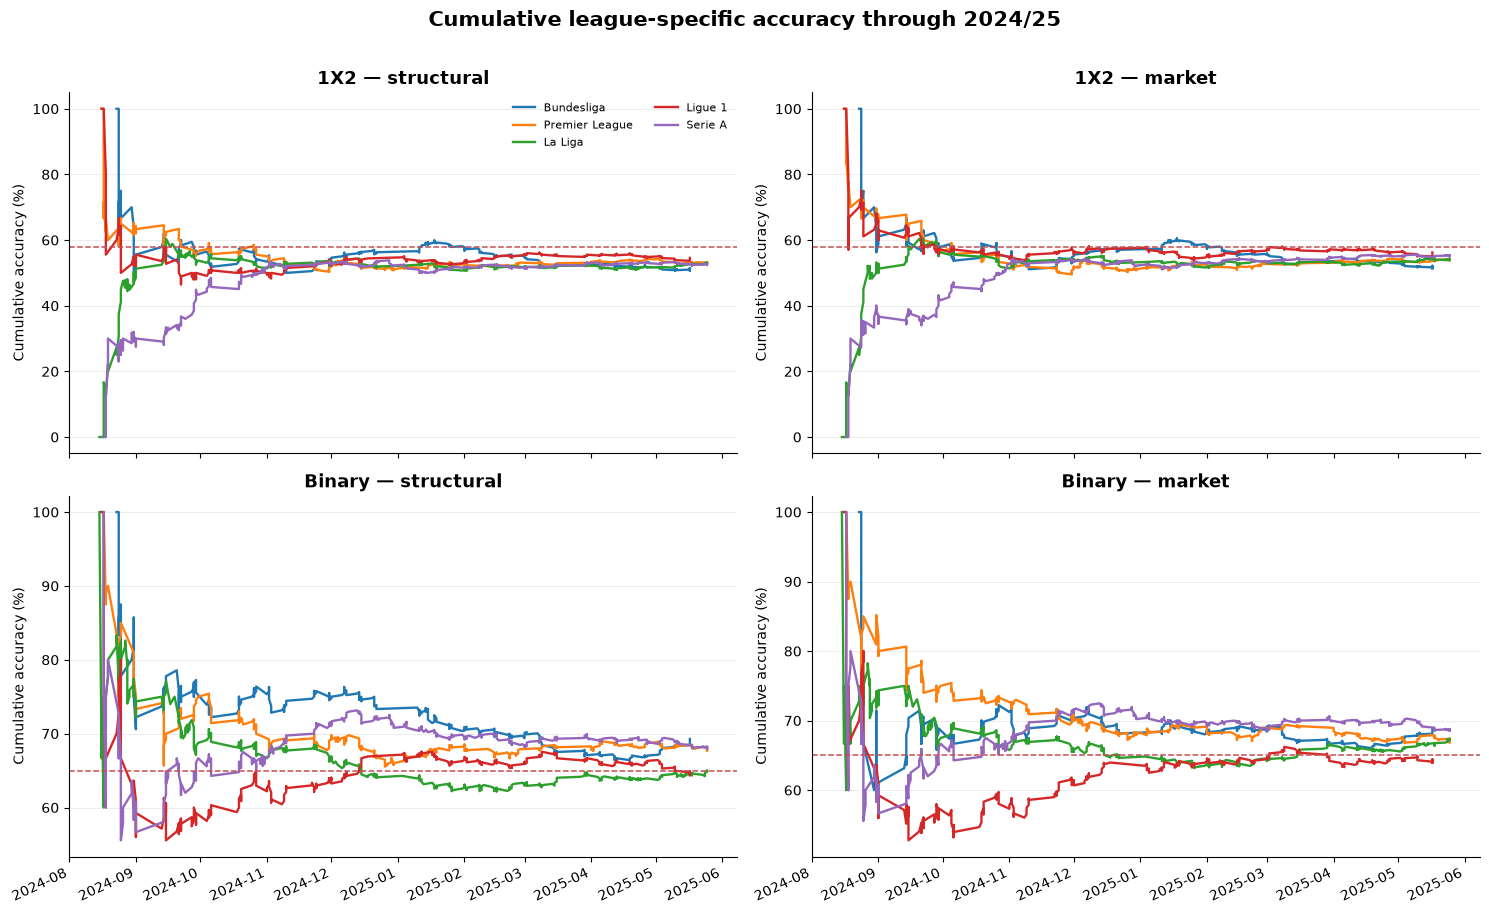

In [20]:
trajectory = league_predictions.sort_values(["scope_code", "branch", "date", "game_id"]).copy()
trajectory["correct_1x2"] = (
    RESULT_LABELS[np.argmax(trajectory[["p_1x2_home", "p_1x2_draw", "p_1x2_away"]].to_numpy(), axis=1)]
    == trajectory["observed_1x2"].to_numpy()
).astype(int)
trajectory["correct_binary"] = (
    (trajectory["p_binary_home"].to_numpy() >= 0.5).astype(int)
    == trajectory["observed_home_win"].to_numpy()
).astype(int)
trajectory["cumulative_1x2_accuracy"] = trajectory.groupby(["scope_code", "branch"])["correct_1x2"].transform(lambda values: values.expanding().mean())
trajectory["cumulative_binary_accuracy"] = trajectory.groupby(["scope_code", "branch"])["correct_binary"].transform(lambda values: values.expanding().mean())

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for column, branch in enumerate(["structural", "market"]):
    for league_id, league_name in LEAGUES.items():
        rows = trajectory.loc[trajectory["scope_code"].eq(league_id) & trajectory["branch"].eq(branch)]
        axes[0, column].plot(rows["date"], 100 * rows["cumulative_1x2_accuracy"], linewidth=1.7, label=league_name)
        axes[1, column].plot(rows["date"], 100 * rows["cumulative_binary_accuracy"], linewidth=1.7, label=league_name)
    axes[0, column].axhline(58, color=COLOURS["target"], linestyle="--", linewidth=1.1)
    axes[1, column].axhline(65, color=COLOURS["target"], linestyle="--", linewidth=1.1)
    axes[0, column].set_title(f"1X2 — {branch}")
    axes[1, column].set_title(f"Binary — {branch}")
    for row in [0, 1]:
        axes[row, column].set_ylabel("Cumulative accuracy (%)")
        axes[row, column].grid(axis="y")
axes[0, 0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle("Cumulative league-specific accuracy through 2024/25", fontsize=15, fontweight="bold", y=1.01)
fig.autofmt_xdate(rotation=25)
fig.tight_layout()
plt.show()

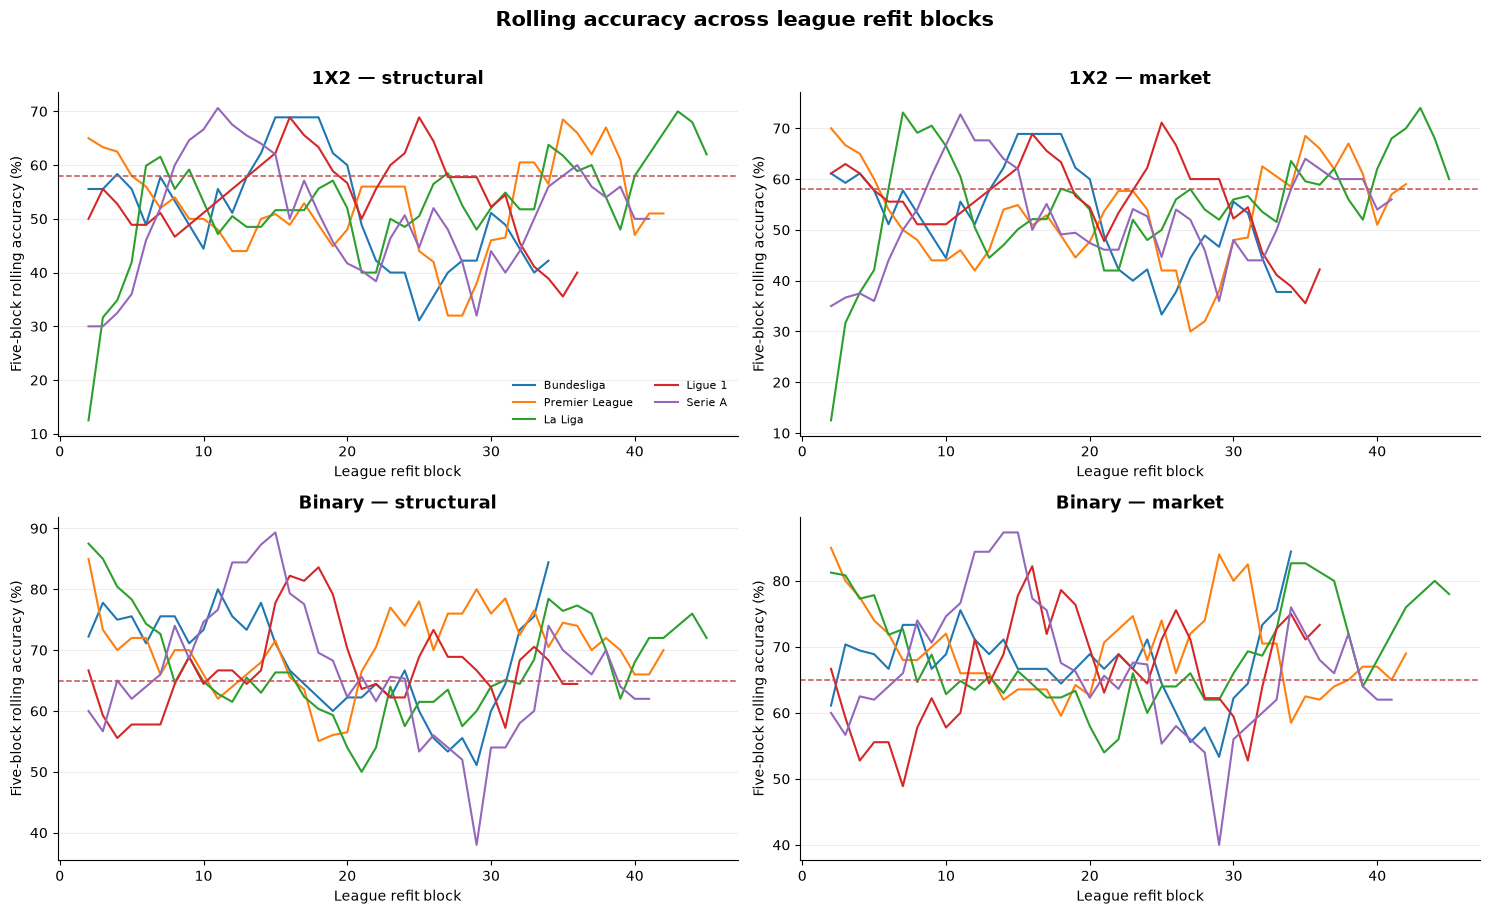

In [21]:
rolling_1x2 = block_performance_1x2.sort_values(["scope_code", "branch", "walk_block"]).copy()
rolling_binary = block_performance_binary.sort_values(["scope_code", "branch", "walk_block"]).copy()
rolling_1x2["rolling_five_block_accuracy"] = rolling_1x2.groupby(["scope_code", "branch"])["accuracy"].transform(lambda values: values.rolling(5, min_periods=2).mean())
rolling_binary["rolling_five_block_accuracy"] = rolling_binary.groupby(["scope_code", "branch"])["accuracy"].transform(lambda values: values.rolling(5, min_periods=2).mean())

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=False)
for column, branch in enumerate(["structural", "market"]):
    for league_id, league_name in LEAGUES.items():
        rows_1x2 = rolling_1x2.loc[rolling_1x2["scope_code"].eq(league_id) & rolling_1x2["branch"].eq(branch)]
        rows_binary = rolling_binary.loc[rolling_binary["scope_code"].eq(league_id) & rolling_binary["branch"].eq(branch)]
        axes[0, column].plot(rows_1x2["walk_block"], 100 * rows_1x2["rolling_five_block_accuracy"], linewidth=1.5, label=league_name)
        axes[1, column].plot(rows_binary["walk_block"], 100 * rows_binary["rolling_five_block_accuracy"], linewidth=1.5, label=league_name)
    axes[0, column].axhline(58, color=COLOURS["target"], linestyle="--", linewidth=1.1)
    axes[1, column].axhline(65, color=COLOURS["target"], linestyle="--", linewidth=1.1)
    axes[0, column].set_title(f"1X2 — {branch}")
    axes[1, column].set_title(f"Binary — {branch}")
    for row in [0, 1]:
        axes[row, column].set_xlabel("League refit block")
        axes[row, column].set_ylabel("Five-block rolling accuracy (%)")
        axes[row, column].grid(axis="y")
axes[0, 0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle("Rolling accuracy across league refit blocks", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

The cumulative lines show whether early results persist or regress toward a stable season estimate. Rolling lines identify temporary good and poor periods, but their small effective sample means they must not be used for post-test retuning.

## 12. Confusion matrices

The pooled models provide one common sample of 1,752 matches. Their confusion matrices summarise which outcomes are confused. Rows are observed classes and columns predicted classes.

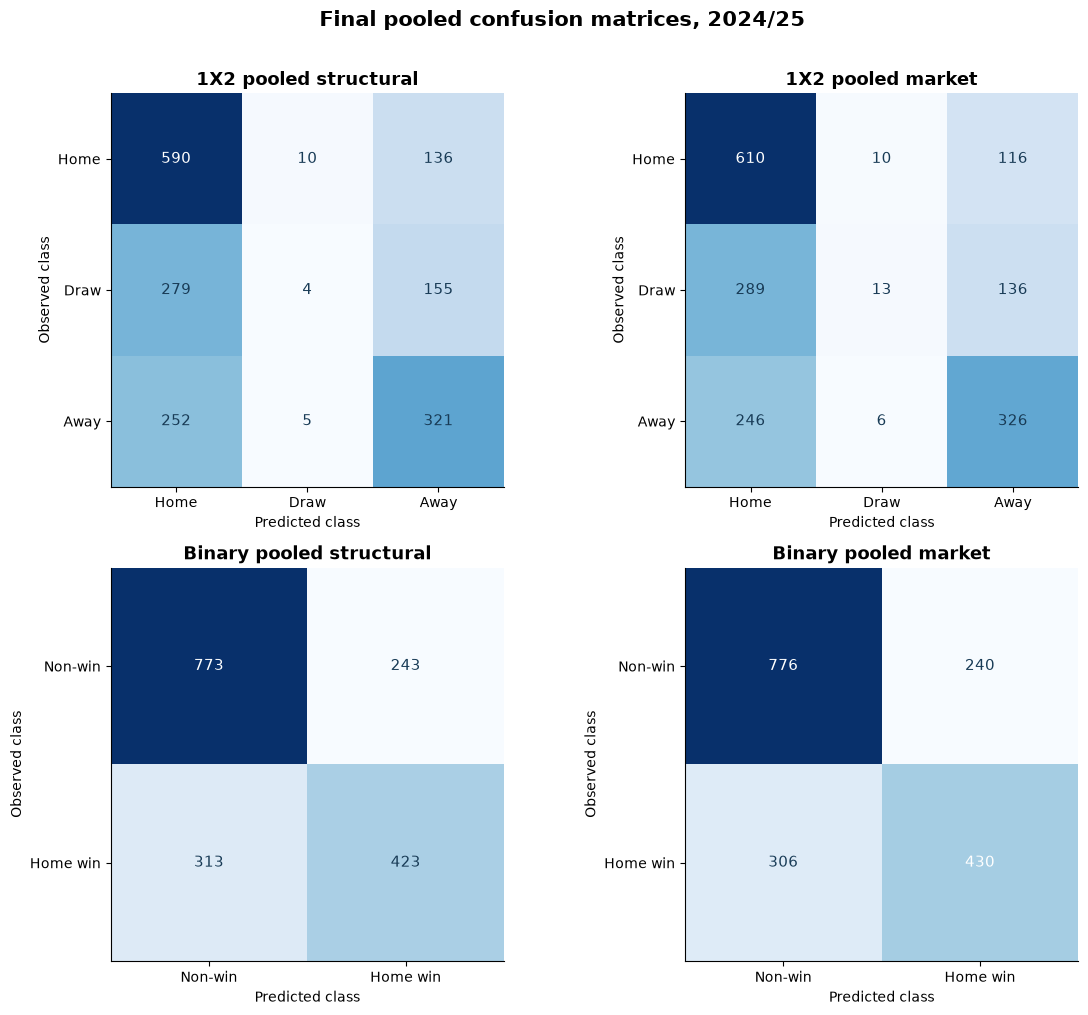

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for column, branch in enumerate(["structural", "market"]):
    rows = locked_predictions.loc[
        locked_predictions["scope_code"].eq("POOLED")
        & locked_predictions["branch"].eq(branch)
    ]
    p_1x2 = rows[["p_1x2_home", "p_1x2_draw", "p_1x2_away"]].to_numpy()
    predicted_1x2 = RESULT_LABELS[np.argmax(p_1x2, axis=1)]
    matrix_1x2 = confusion_matrix(rows["observed_1x2"], predicted_1x2, labels=RESULT_LABELS)
    matrix_binary = confusion_matrix(
        rows["observed_home_win"], (rows["p_binary_home"] >= 0.5).astype(int), labels=[0, 1]
    )
    for row_index, (matrix, labels, title) in enumerate([
        (matrix_1x2, ["Home", "Draw", "Away"], f"1X2 pooled {branch}"),
        (matrix_binary, ["Non-win", "Home win"], f"Binary pooled {branch}"),
    ]):
        ax = axes[row_index, column]
        ax.imshow(matrix, cmap="Blues")
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center", color="white" if matrix[i, j] > matrix.max() * 0.55 else "#183B56", fontsize=11)
        ax.set_xticks(range(len(labels)), labels)
        ax.set_yticks(range(len(labels)), labels)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("Observed class")
        ax.set_title(title)
fig.suptitle("Final pooled confusion matrices, 2024/25", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

The 1X2 matrices make draw behaviour explicit. A high overall accuracy with very few predicted draws would indicate that the model mostly separates home and away wins. The binary matrices show the trade-off between detecting home wins and correctly retaining home non-wins.

## 13. Probability calibration

Calibration is evaluated on out-of-time probabilities. For 1X2, each class is treated one-versus-rest. For binary prediction, the curve uses the home-win probability directly. Eight quantile bins keep bin sizes approximately balanced.

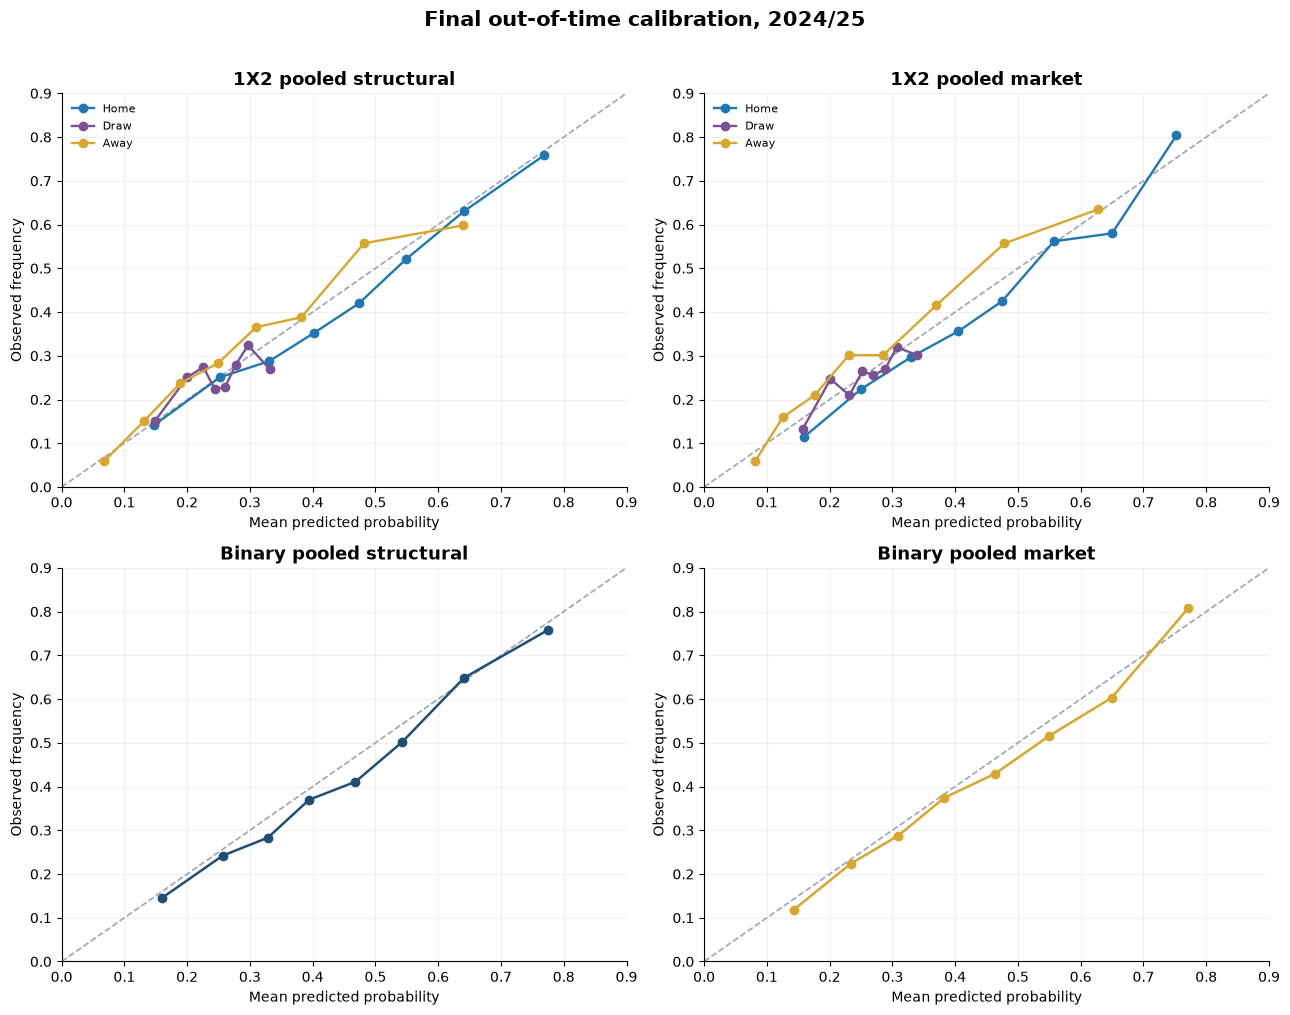

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for column, branch in enumerate(["structural", "market"]):
    rows = locked_predictions.loc[
        locked_predictions["scope_code"].eq("POOLED")
        & locked_predictions["branch"].eq(branch)
    ]
    axes[0, column].plot([0, 1], [0, 1], linestyle="--", color="#9AA6B2", linewidth=1.2)
    for label, probability_column, colour in [
        ("Home", "p_1x2_home", "#1F77B4"),
        ("Draw", "p_1x2_draw", "#7A5195"),
        ("Away", "p_1x2_away", "#D9A62E"),
    ]:
        observed = rows["observed_1x2"].eq(label[0]).astype(int)
        observed_rate, predicted_mean = calibration_curve(observed, rows[probability_column], n_bins=8, strategy="quantile")
        axes[0, column].plot(predicted_mean, observed_rate, marker="o", linewidth=1.7, label=label, color=colour)
    axes[0, column].set_title(f"1X2 pooled {branch}")
    axes[0, column].legend(frameon=False, fontsize=8)

    axes[1, column].plot([0, 1], [0, 1], linestyle="--", color="#9AA6B2", linewidth=1.2)
    observed_rate, predicted_mean = calibration_curve(rows["observed_home_win"], rows["p_binary_home"], n_bins=8, strategy="quantile")
    axes[1, column].plot(predicted_mean, observed_rate, marker="o", linewidth=1.8, color=COLOURS[branch])
    axes[1, column].set_title(f"Binary pooled {branch}")
    for row_index in [0, 1]:
        axes[row_index, column].set_xlabel("Mean predicted probability")
        axes[row_index, column].set_ylabel("Observed frequency")
        axes[row_index, column].set_xlim(0, 0.9)
        axes[row_index, column].set_ylim(0, 0.9)
        axes[row_index, column].grid(alpha=0.18)
fig.suptitle("Final out-of-time calibration, 2024/25", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

Points above the diagonal indicate underprediction; points below it indicate overprediction. Calibration conclusions are strongest for the pooled sample and more uncertain for individual leagues.

## 14. Final interpretation and limitations

This evaluation is stricter than an ordinary random train–test split:

- the entire test season occurs after model development;
- every refit uses only completed earlier blocks;
- all algorithms, hyperparameters, features, ensembles, and thresholds remain locked;
- the model is allowed to learn from the season only at the predefined refit frequency.

Important limitations remain:

- official matchday labels are unavailable, so blocks are reconstructed from fixture dates and team participation;
- precomputed 2024/25 feature rows use realised earlier results, which is valid for retrospective day-before prediction but not a preseason forecast of all fixtures;
- market coverage is slightly below 100% for the direct-market benchmark;
- Wilson intervals do not model serial dependence or common league shocks;
- comparing many league and branch rows increases the chance of apparently large differences;
- the final season is now open and must not be used to redesign the models reported here.

In [24]:
final_summary = pd.DataFrame([
    {
        "item": "Prediction horizon",
        "result": f"{len(final_test_blocked):,} matches; {final_test_blocked['date'].min():%d %b %Y} to {final_test_blocked['date'].max():%d %b %Y}",
    },
    {
        "item": "League-specific refit blocks",
        "result": f"{league_block_summary.shape[0]} blocks: {(league_block_summary['walk_block_type'] == 'complete_round').sum()} complete and {(league_block_summary['walk_block_type'] == 'weekly_exception').sum()} weekly exceptions",
    },
    {"item": "Pooled refit blocks", "result": f"{len(pooled_weeks)} common football weeks"},
    {"item": "Locked classifier branches", "result": "12 for 1X2 and 12 for binary"},
    {"item": "Poisson refits", "result": f"{league_block_summary.shape[0]} successful league-block fits"},
    {"item": "2024/25 used for model choice", "result": "No"},
])
display(final_summary.style.hide(axis="index"))

item,result
Prediction horizon,"1,752 matches; 15 Aug 2024 to 25 May 2025"
League-specific refit blocks,198 blocks: 162 complete and 36 weekly exceptions
Pooled refit blocks,39 common football weeks
Locked classifier branches,12 for 1X2 and 12 for binary
Poisson refits,198 successful league-block fits
2024/25 used for model choice,No


## 15. Reproducible exports for thesis reporting

The analytical notebook remains the source of truth. The next cell writes
compact machine-readable copies of its final prediction rows and summary
tables to an ignored cache directory. A separate reporting notebook can
therefore translate labels and create publication figures without refitting
any model or parsing rendered notebook output.


In [25]:
REPORTING_DIR = PROJECT_ROOT / ".cache" / "thesis_cs"
REPORTING_DIR.mkdir(parents=True, exist_ok=True)

locked_predictions.to_parquet(
    REPORTING_DIR / "match_predictions_2024_25.parquet",
    index=False,
    compression="zstd",
)

reporting_tables = {
    "model_registry.csv": locked_registry_summary,
    "prediction_horizon.csv": prediction_horizon,
    "refit_log.csv": refit_log,
    "multiclass_by_scope.csv": final_multiclass_summary,
    "binary_by_scope.csv": final_binary_summary,
    "multiclass_overall.csv": overall_1x2,
    "binary_overall.csv": overall_binary,
    "league_vs_pooled.csv": league_vs_pooled,
    "multiclass_benchmarks.csv": reference_1x2_summary,
    "binary_benchmarks.csv": reference_binary_summary,
    "multiclass_by_block.csv": block_performance_1x2,
    "binary_by_block.csv": block_performance_binary,
}
for filename, table in reporting_tables.items():
    table.to_csv(REPORTING_DIR / filename, index=False, encoding="utf-8")

print(f"Thesis-reporting artifacts exported to: {REPORTING_DIR}")


Thesis-reporting artifacts exported to: C:\Users\cerve\Desktop\DP\match_prediction\.cache\thesis_cs


## 16. Conclusion

The locked models have now completed their only final out-of-time test. The notebook reports final accuracy and probability quality overall, by league, by branch, by league block, and cumulatively through 2024/25. It also compares pooled and league-specific fitting, direct binary and aggregated 1X2 probabilities, Poisson scores, market probabilities, and expanding baselines.

Notebook 07 uses a different prediction question. It simulates complete league tables from four information snapshots—preseason, approximately 25%, 50%, and 75% of completed fixtures—using the Poisson score model. That method is suitable for long-range simulation because it can generate future scores without pretending that future rolling features or future market odds are already known.